# Import pypsa and model

In [1]:
import tz_pypsa
import pandas as pd
from tz_pypsa.model import Model
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# n=Model.load_csv_from_dir('./examples/two-region-capacity-expansion', backstop=True)
# n=Model.load_csv_from_dir('./examples/india-example', backstop=True)
n=Model.load_csv_from_dir('../stock_models/India',
                          year=2023,
                          frequency='1h',
                          timesteps=8760,
                          backstop=False)

INFO:pypsa.io:Imported network India has buses, carriers, generators, links, loads, storage_units


In [3]:
# # # Test out subselection of nodes
# select_nodes = ['INDSO']
# n.buses = n.buses[n.buses.index.isin(select_nodes)]
# n.loads = n.loads[n.loads.index.isin(select_nodes)]
# n.generators = n.generators[n.generators['bus'].isin(select_nodes)]
# n.lines = n.lines[((n.lines['bus0'].isin(select_nodes)) | (n.lines['bus1'].isin(select_nodes)))]

# Inspect the network as a sense check

(<matplotlib.collections.PatchCollection at 0x152fce790>,
 <matplotlib.collections.LineCollection at 0x152fcf710>)

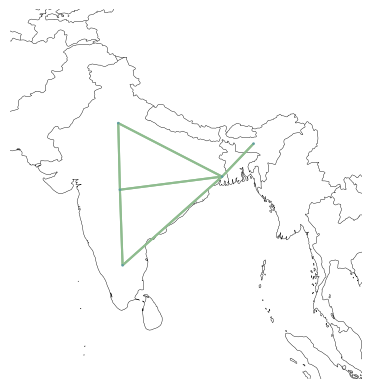

In [4]:
n.plot(margin=0.8)

<Axes: xlabel='snapshot'>

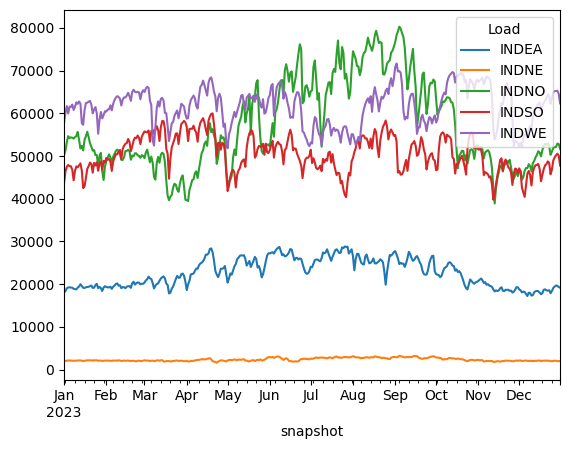

In [5]:
# Look at the load
# n.loads_t.p_set.head(744).plot()
n.loads_t.p_set.resample('D').mean().plot()

# Solve the model

In [6]:
n.optimize(solver_name='highs')

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00,  7.99it/s]
INFO:linopy.io: Writing time: 4.6s


Running HiGHS 1.9.0 (git hash: fa40bdf): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [9e-01, 1e+00]
  Cost   [1e-02, 1e+02]
  Bound  [0e+00, 0e+00]
  RHS    [4e-03, 9e+04]
Presolving model
70080 rows, 823234 cols, 989515 nonzeros  0s
69144 rows, 490309 cols, 655654 nonzeros  1s
69144 rows, 490039 cols, 655384 nonzeros  1s
Presolve : Reductions: rows 69144(-2269902); columns 490039(-508601); elements 655384(-3076468)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     1.2504492948e+10 Pr: 44112(8.60899e+08) 1s
     109681     1.7874065560e+10 Pr: 0(0); Du: 0(3.36498e-07) 3s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-m22chidn
Model status        : Optimal
Simplex   iterations: 109681
Objective value     :  1.7874065560e+10
Relative P-D gap    :  6.5285420917e-13
HiGHS run time      :          3.98
Writing the solution 

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 998640 primals, 2339046 duals
Objective: 1.79e+10
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-fix-p-ramp_limit_up, Generator-fix-p-ramp_limit_down, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-state_of_charge_set, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

# Look at outputs

In [7]:
# n.export_to_csv_folder('output')
# n.storage_units_t.state_of_charge_set.dropna()
n.storage_units_t.state_of_charge.head(100)

StorageUnit,hydro-pumped-storage-INDEA-water,hydro-pumped-storage-INDWE-water,hydro-pumped-storage-INDSO-water,batteries-INDSO
snapshot,,,,
2023-01-01 00:00:00,-0.000000,-0.0,-0.0,-0.0
2023-01-01 01:00:00,-0.000000,-0.0,-0.0,-0.0
2023-01-01 02:00:00,133.113283,-0.0,-0.0,-0.0
2023-01-01 03:00:00,472.110746,-0.0,-0.0,-0.0
2023-01-01 04:00:00,986.994027,-0.0,-0.0,-0.0
...,...,...,...,...
2023-01-04 23:00:00,3600.000000,7360.0,8424.0,-0.0
2023-01-05 00:00:00,3600.000000,7360.0,8424.0,-0.0
2023-01-05 01:00:00,3600.000000,7360.0,8424.0,-0.0


In [8]:
n.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt,technology,year
Generator,,,,,,,,,,,,,,,,,,,,,
Bio-power - Bagasse-INDEA-agricultural-waste-solids,INDEA,PQ,biomass-INDEA,463.0,0.0,False,0.0,inf,0.0,1.0,...,1,0,NaN,NaN,1.0,1.0,1.0,463.0,biomass,2023
Bio-power - Bagasse-INDNE-agricultural-waste-solids,INDNE,PQ,biomass-INDNE,0.0,0.0,False,0.0,inf,0.0,1.0,...,1,0,NaN,NaN,1.0,1.0,1.0,0.0,biomass,2023
Bio-power - Bagasse-INDNO-agricultural-waste-solids,INDNO,PQ,biomass-INDNO,2600.0,0.0,False,0.0,inf,0.0,1.0,...,1,0,NaN,NaN,1.0,1.0,1.0,2600.0,biomass,2023
Bio-power - Bagasse-INDSO-agricultural-waste-solids,INDSO,PQ,biomass-INDSO,3372.0,0.0,False,0.0,inf,0.0,1.0,...,1,0,NaN,NaN,1.0,1.0,1.0,3372.0,biomass,2023
Bio-power - Bagasse-INDWE-agricultural-waste-solids,INDWE,PQ,biomass-INDWE,2998.0,0.0,False,0.0,inf,0.0,1.0,...,1,0,NaN,NaN,1.0,1.0,1.0,2998.0,biomass,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
supercritical-INDNO-coal,INDNO,PQ,supercritical-INDNO,21740.0,0.0,False,0.0,inf,0.0,1.0,...,1,0,0.6,0.6,1.0,1.0,1.0,21740.0,supercritical,2023
supercritical-INDSO-coal,INDSO,PQ,supercritical-INDSO,19500.0,0.0,False,0.0,inf,0.0,1.0,...,1,0,0.6,0.6,1.0,1.0,1.0,19500.0,supercritical,2023
supercritical-INDWE-coal,INDWE,PQ,supercritical-INDWE,31230.0,0.0,False,0.0,inf,0.0,1.0,...,1,0,0.6,0.6,1.0,1.0,1.0,31230.0,supercritical,2023


In [9]:
n.loads_t.p_set.sum()

Load
INDEA    1.985573e+08
INDNE    2.064433e+07
INDNO    4.994662e+08
INDSO    4.421023e+08
INDWE    5.393337e+08
dtype: float64

## Define some helper functions

In [10]:
# Look at monthly generation
def monthly_generation(tech):
    # columns = n.generators_t.p.reset_index(level='snapshot', drop=True).filter(regex=tech).resample('M').sum()
    columns = n.generators_t.p.filter(regex=tech).resample('M').sum()
    return columns

# Look at monthly generation
def daily_generation(tech):
    # columns = n.generators_t.p.reset_index(level='snapshot', drop=True).filter(regex=tech).resample('M').sum()
    columns = n.generators_t.p.filter(regex=tech).resample('D').sum()
    return columns

## Plot the network and flows

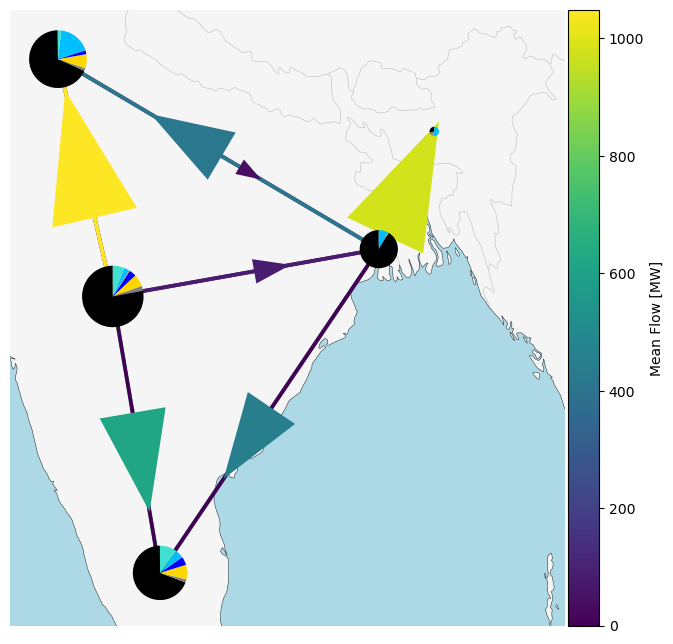

In [11]:
tz_pypsa.plotting.network_map(network = n)

## Look at monthly generation for certain techs

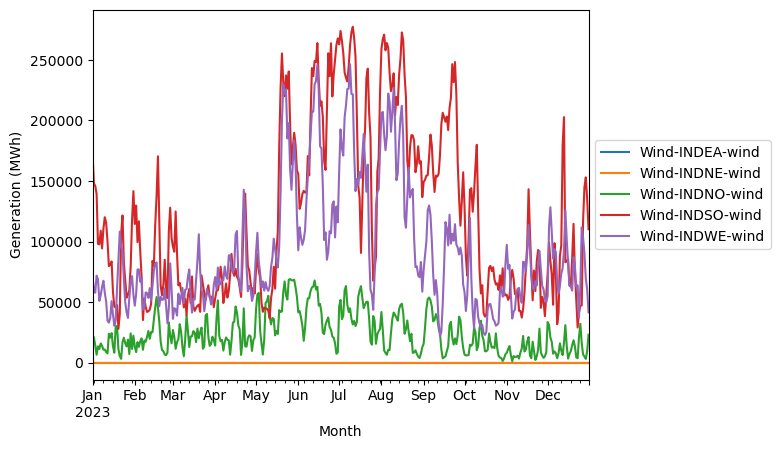

In [12]:
# Plot monthly generation for a tech using fn above
ax = daily_generation('-wind.*').plot()
ax.set_xlabel('Month')
ax.set_ylabel('Generation (MWh)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [13]:
tz_pypsa.plotting.energy_balance(network=n,
                                 period = '2023',
                                 )

## Rough statistics

In [14]:
n.statistics().round(2)

Optimal Capacity  Installed Capacity  \
Generator   Agricultural Waste Solids            9433.0              9433.0   
            Bioenergy                             923.0               923.0   
            Coal                               229449.0            229449.0   
            Gas                                 24514.0             24514.0   
            Oil                                   349.0               349.0   
            Onshore Wind                        45882.0             45882.0   
            Solar                               81769.0             81769.0   
            Uranium                              7540.0              7540.0   
            Waste                                1197.0              1197.0   
            Water                               39403.0             39403.0   
Link        Transmission                        72500.0             72500.0   
Load        -                                       0.0                 0.0   
StorageUnit Pumped Hydro                         4846.0              4846.0   

                                             Supply    Withdrawal  \
Generator   Agricultural Waste Solids  0.000000e+00  0.000000e+00   
            Bioenergy                  2.021518e+06  0.000000e+00   
            Coal                       1.263961e+09  0.000000e+00   
            Gas                        3.163202e+07  0.000000e+00   
            Oil                        2.168100e+05  0.000000e+00   
            Onshore Wind               8.789382e+07  0.000000e+00   
            Solar                      1.131329e+08  0.000000e+00   
            Uranium                    5.283756e+07  0.000000e+00   
            Waste                      3.953109e+06  0.000000e+00   
            Water                      1.476805e+08  0.000000e+00   
Link        Transmission               2.895678e+07  3.217420e+07   
Load        -                          0.000000e+00  1.700104e+09   
StorageUnit Pumped Hydro               3.345449e+04  4.181811e+04   

                                       Energy Balance  Transmission  \
Generator   Agricultural Waste Solids    0.000000e+00          0.00   
            Bioenergy                    2.021518e+06          0.00   
            Coal                         1.263961e+09          0.00   
            Gas                          3.163202e+07          0.00   
            Oil                          2.168100e+05          0.00   
            Onshore Wind                 8.789382e+07          0.00   
            Solar                        1.131329e+08          0.00   
            Uranium                      5.283756e+07          0.00   
            Waste                        3.953109e+06          0.00   
            Water                        1.476805e+08          0.00   
Link        Transmission                -3.217420e+06   32174201.45   
Load        -                           -1.700104e+09          0.00   
StorageUnit Pumped Hydro                -8.363620e+03          0.00   

                                       Capacity Factor   Curtailment  \
Generator   Agricultural Waste Solids             0.00  1.549653e+07   
            Bioenergy                             0.25  4.849810e+05   
            Coal                                  0.63  7.460119e+08   
            Gas                                   0.15  1.831106e+08   
            Oil                                   0.07  2.840430e+06   
            Onshore Wind                          0.22  0.000000e+00   
            Solar                                 0.16  0.000000e+00   
            Uranium                               0.80  2.759270e+03   
            Waste                                 0.38  3.002681e+06   
            Water                                 0.43  0.000000e+00   
Link        Transmission                          0.05  0.000000e+00   
Load        -                                      NaN  0.000000e+00   
StorageUnit Pumped Hydro          

## Find monthly capacity factors

In [15]:
# monthly_generation('Solar').head()
columns = n.generators_t.p.resample('M').sum()
capacity = n.generators.p_nom.to_frame().T

cf = columns.div(capacity.iloc[0]*24*30).filter(regex='coal')
cf['Average_Capacity_Factor'] = cf.mean(axis=1)

cf

Generator,circulating-fluidized-bed-INDSO-coal,circulating-fluidized-bed-INDWE-coal,coal-unspecified-INDEA-coal,coal-unspecified-INDSO-coal,coal-unspecified-INDWE-coal,steam-turbine-INDEA-coal,subcritical-INDEA-coal,subcritical-INDNE-coal,subcritical-INDNO-coal,subcritical-INDSO-coal,subcritical-INDWE-coal,supercritical-INDEA-coal,supercritical-INDNO-coal,supercritical-INDSO-coal,supercritical-INDWE-coal,ultrasupercritical-INDNO-coal,ultrasupercritical-INDWE-coal,Average_Capacity_Factor
snapshot,,,,,,,,,,,,,,,,,,
2023-01-31,0.413333,0.413333,0.413333,0.413333,0.413333,0.413333,0.413343,0.830347,0.596901,0.488939,0.420573,0.726373,0.987267,0.937406,0.851356,1.033333,1.033333,0.635245
2023-02-28,0.373333,0.373333,0.373333,0.375831,0.373333,0.373333,0.373333,0.784323,0.459447,0.515011,0.379552,0.706787,0.865051,0.925467,0.827873,0.933333,0.933333,0.585059
2023-03-31,0.439293,0.413333,0.413333,0.453288,0.413333,0.413333,0.414100,0.866826,0.461694,0.720593,0.416668,0.840309,0.854546,1.028646,0.875091,0.984095,1.022675,0.648892
2023-04-30,0.407749,0.400000,0.400000,0.419052,0.400000,0.400000,0.431097,0.899464,0.522968,0.727764,0.406756,0.922320,0.851695,0.996407,0.897805,0.950707,0.991895,0.648569
2023-05-31,0.413333,0.413333,0.413333,0.413333,0.413333,0.413333,0.434383,0.931719,0.562260,0.522361,0.414249,0.946606,0.907892,0.997731,0.828207,1.005002,1.015386,0.649753
2023-06-30,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,0.437386,0.917636,0.635535,0.515279,0.403631,0.950563,0.964463,0.954414,0.834986,0.996684,0.977295,0.646345
2023-07-31,0.413333,0.413333,0.413333,0.413333,0.413333,0.413333,0.435201,0.928136,0.628979,0.444997,0.413976,0.957070,0.993676,0.881247,0.678238,1.026051,0.934124,0.635394
2023-08-31,0.413333,0.413333,0.413333,0.413851,0.413333,0.413333,0.421957,0.892256,0.747915,0.534817,0.416022,0.920100,1.032505,0.996235,0.814218,1.033333,0.977122,0.662765
2023-09-30,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,0.430746,0.874188,0.731101,0.494428,0.414212,0.908097,0.982071,0.940289,0.826105,0.997152,0.979037,0.645731


In [16]:
def process_generator_data(generator_type):
    n_gen = n.generators_t.p #.reset_index(level='period', drop=True)
    # Resample the data to monthly sums
    n_gen_monthly = n_gen.resample('M').sum()
    
    # Filter the data for the specified generator type
    generator_monthly = n_gen_monthly.filter(regex=generator_type)
    
    # Calculate the total generation for the specified generator type
    generator_monthly[f'Total_{generator_type}_Generation'] = generator_monthly.sum(axis=1)
    
    return generator_monthly

# Example usage
wind_gen_monthly = process_generator_data('Wind')
solar_gen_monthly = process_generator_data('Solar')
coal_gen_monthly = process_generator_data('critical').sum(axis=1)

<Axes: title={'center': 'Total Coal Generation Monthly'}, xlabel='snapshot', ylabel='Generation (MWh)'>

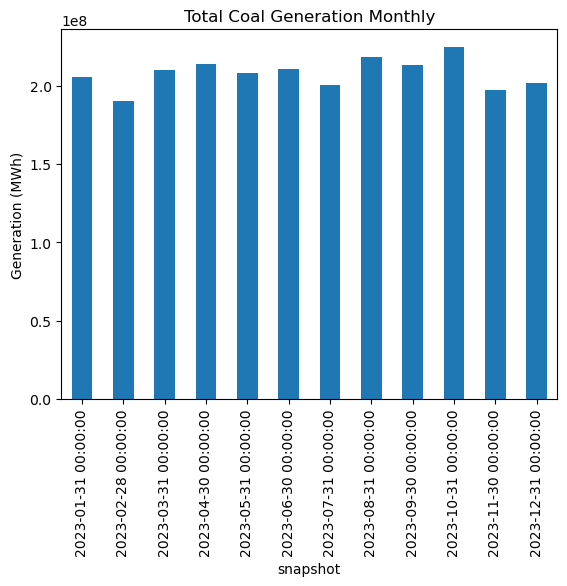

In [17]:
coal_gen_monthly.plot(kind='bar', title='Total Coal Generation Monthly', ylabel='Generation (MWh)')

<Axes: title={'center': 'Total Wind Generation Monthly'}, xlabel='snapshot', ylabel='Generation (MWh)'>

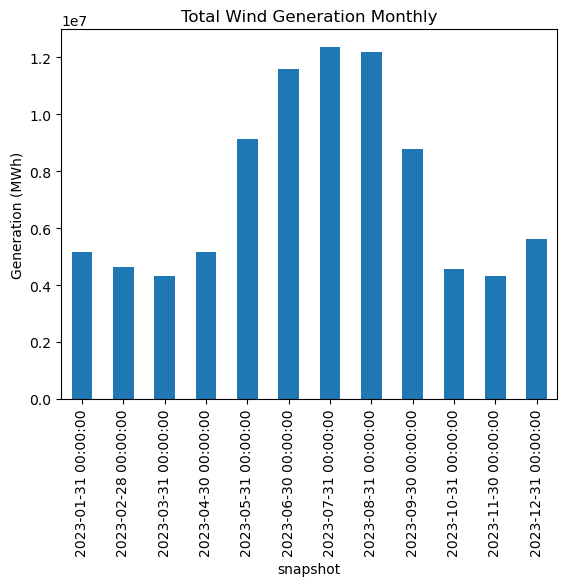

In [18]:
wind_gen_monthly['Total_Wind_Generation'].plot(kind='bar', title='Total Wind Generation Monthly', ylabel='Generation (MWh)')

<Axes: title={'center': 'Total Solar Generation Monthly'}, xlabel='snapshot', ylabel='Generation (MWh)'>

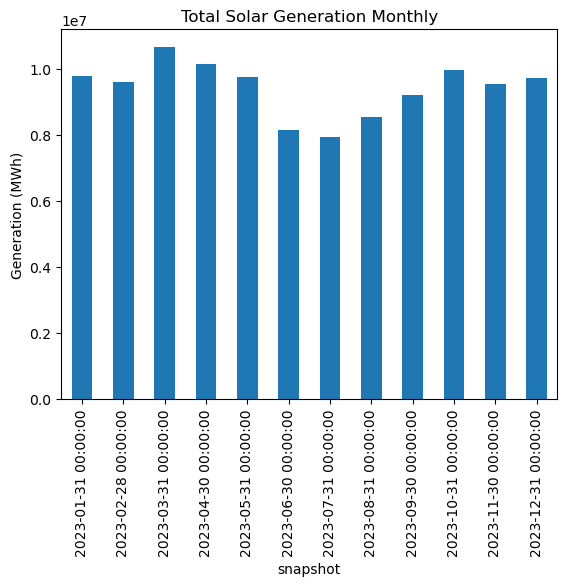

In [19]:
solar_gen_monthly['Total_Solar_Generation'].plot(kind='bar', title='Total Solar Generation Monthly', ylabel='Generation (MWh)')

## Peak demand and curtailment

In [20]:
# Some of the lines are constrained - which should lead to curtailment in renewables
# Currently gas generators are switching off, need to stop this behaviour
# Looking at curtailment confirms this
n.links_t.p0.max()

Link
INDNO-INDEA-interconnector-2023     4000.000000
INDEA-INDNO-interconnector-2023     8000.000000
INDNO-INDWE-interconnector-2023     4000.000000
INDWE-INDNO-interconnector-2023    17645.872122
INDEA-INDSO-interconnector-2023     6000.000000
INDSO-INDEA-interconnector-2023       -0.000000
INDWE-INDSO-interconnector-2023    14588.536061
INDSO-INDWE-interconnector-2023     2872.031080
INDEA-INDNE-interconnector-2023     1950.000000
INDNE-INDEA-interconnector-2023       25.436735
INDEA-INDWE-interconnector-2023       -0.000000
INDWE-INDEA-interconnector-2023     5500.000000
dtype: float64

In [21]:
# More curtailment is happening in gas than it is actually generating
(n.statistics.curtailment()/n.statistics.supply()).sort_values(ascending=False)

component    carrier                  
StorageUnit  Pumped Hydro                 1269.166757
Generator    Oil                            13.101010
             Gas                             5.788775
             Waste                           0.759575
             Coal                            0.590217
             Bioenergy                       0.239909
             Uranium                         0.000052
             Agricultural Waste Solids            NaN
             Onshore Wind                         NaN
             Solar                                NaN
             Water                                NaN
Link         Transmission                         NaN
dtype: float64

## Hourly dispatch

In [22]:
def plot_hourly_dispatch(start_date, end_date):
    # Extract the hourly dispatch data for the given date range
    hourly_dispatch = n.generators_t.p.loc[start_date:end_date].merge(
        n.storage_units_t.p.loc[start_date:end_date], how='outer', left_on='snapshot', right_on='snapshot'
    )

    combined_carriers = pd.concat([n.storage_units.carrier, n.generators.carrier])
    
    # Group the hourly dispatch data by carrier
    hourly_dispatch_grouped = hourly_dispatch.groupby(combined_carriers, axis=1).sum()
    
    # Create an interactive Plotly area chart
    fig = px.area(hourly_dispatch_grouped, title=f'Hourly Dispatch from {start_date} to {end_date} by Carrier')
    
    # Update layout with figure size
    fig.update_layout(
        xaxis_title='Hour',
        yaxis_title='Dispatch (MW)',
        legend_title='Carrier',
        width=1000,  # specify the width
        height=600,  # specify the height
        xaxis=dict(
            rangeslider=dict(
                visible=True
            ),
            type="date"
        )
    )
    
    # Show the plot
    fig.show()

In [23]:
# hourly dispatch plotting function
plot_hourly_dispatch('2023-01-01', 
                     '2023-07-31')

## Pumped storage dispatch

<Axes: xlabel='snapshot'>

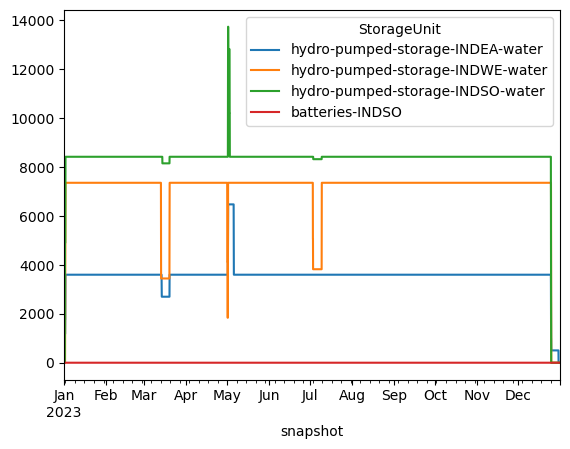

In [24]:
n.storage_units_t.state_of_charge.plot()

## Electricity prices

In [25]:
# Create an interactive plot with a scrollable window on the x-axis
fig = px.line(n.buses_t.marginal_price, title='Marginal Price Over Time')

# Update layout to include a range slider
fig.update_layout(
    xaxis=dict(
        rangeslider=dict(
            visible=True
        ),
        type="date"
    ),
    yaxis_title='Marginal Price'
)

# Show the plot
fig.show()

# Comparison against known data

## Monthly generation

In [26]:
# Get monthly generation
mgen = n.generators_t.p.resample('M').sum().multiply(1e-6)

# Sum together the columns which have the same name when you remove the last '-' and 2 letters
mgen.columns =mgen.columns.str.replace(r'-..$', '', regex=True)
mgen = mgen.groupby(mgen.columns, axis=1).sum()

# Group together Bio-power columns
mgen['Bio-power'] = mgen.filter(like='Bio-power').sum(axis=1)
mgen = mgen.drop(columns=mgen.filter(like='Bio-power').columns.difference(['Bio-power']))

# Group together Solar columns
mgen['Solar'] = mgen.filter(like='Solar').sum(axis=1)
mgen = mgen.drop(columns=mgen.filter(like='Solar').columns.difference(['Solar']))

# Group together hydro columns
mgen['Hydro'] = mgen.filter(like='hydro').sum(axis=1)
mgen = mgen.drop(columns=mgen.filter(like='hydro').columns.difference(['hydro']))

# Rename index
mgen.index = mgen.index.to_period('M')

In [27]:
# Create a dictionary for grouping columns
grouping_dict = {
    'Bio-power': 'Bio-power',
    'Solar': 'Solar', 
    'Wind': 'Wind', 
    'circulating-fluidized-bed': 'Coal',
    'coal-unspecified': 'Coal',
    'combined-cycle': 'Oil-Gas',
    'gas-turbine': 'Oil-Gas', 
    'hydro-reservoir': 'Hydro',
    'hydro-run-of-river': 'Small-Hydro',
    'hydro-unspecified': 'Hydro',
    'Hydro': 'Hydro',
    'internal-combustion-combined-cycle': 'Oil-Gas',
    'oil-unspecified': 'Oil-Gas',
    'pressurized-heavy-water-reactor': 'Nuclear',
    'pressurized-water-reactor': 'Nuclear',
    'steam-turbine': 'Oil-Gas', 
    'subcritical': 'Coal', 
    'supercritical': 'Coal', 
    'ultrasupercritical': 'Coal'
}

# Group columns by the text before '-IND' and sum
mgen_grouped = mgen.groupby(mgen.columns.str.split('-IND').str[0].map(grouping_dict), axis=1).sum()
mgen_grouped.columns

Index(['Bio-power', 'Coal', 'Hydro', 'Nuclear', 'Oil-Gas', 'Solar', 'Wind'], dtype='object', name='Generator')

In [28]:
# Pull in outturn data
# Remember that MU is Millions of Units (of kWh), so 1 MU is 1 GWh
outturn_gen = (
    pd
    .read_excel('./india_gen_2023.xlsx')
    .iloc[:-6]
    .set_index('Parameter')
    .T
    .multiply(0.001)
)
outturn_gen.index.name = 'snapshot'
outturn_gen.columns = outturn_gen.columns.str.replace(r' - .*$', '', regex=True)
outturn_gen.columns.name = 'Generator'
outturn_gen.index = pd.to_datetime(outturn_gen.index).to_period('M')
outturn_gen = outturn_gen.rename(columns={'Bio Power': 'Bio-power','Oil & Gas': 'Oil-Gas'})

# Merge the two columns containing 'hydro' together
outturn_gen['Hydro'] = outturn_gen.filter(like='Hydro').sum(axis=1)
outturn_gen = outturn_gen.drop(columns=outturn_gen.filter(like='Hydro').columns.difference(['Hydro']))

# Arrange the columns alphabetically
outturn_gen = outturn_gen[sorted(outturn_gen.columns)]

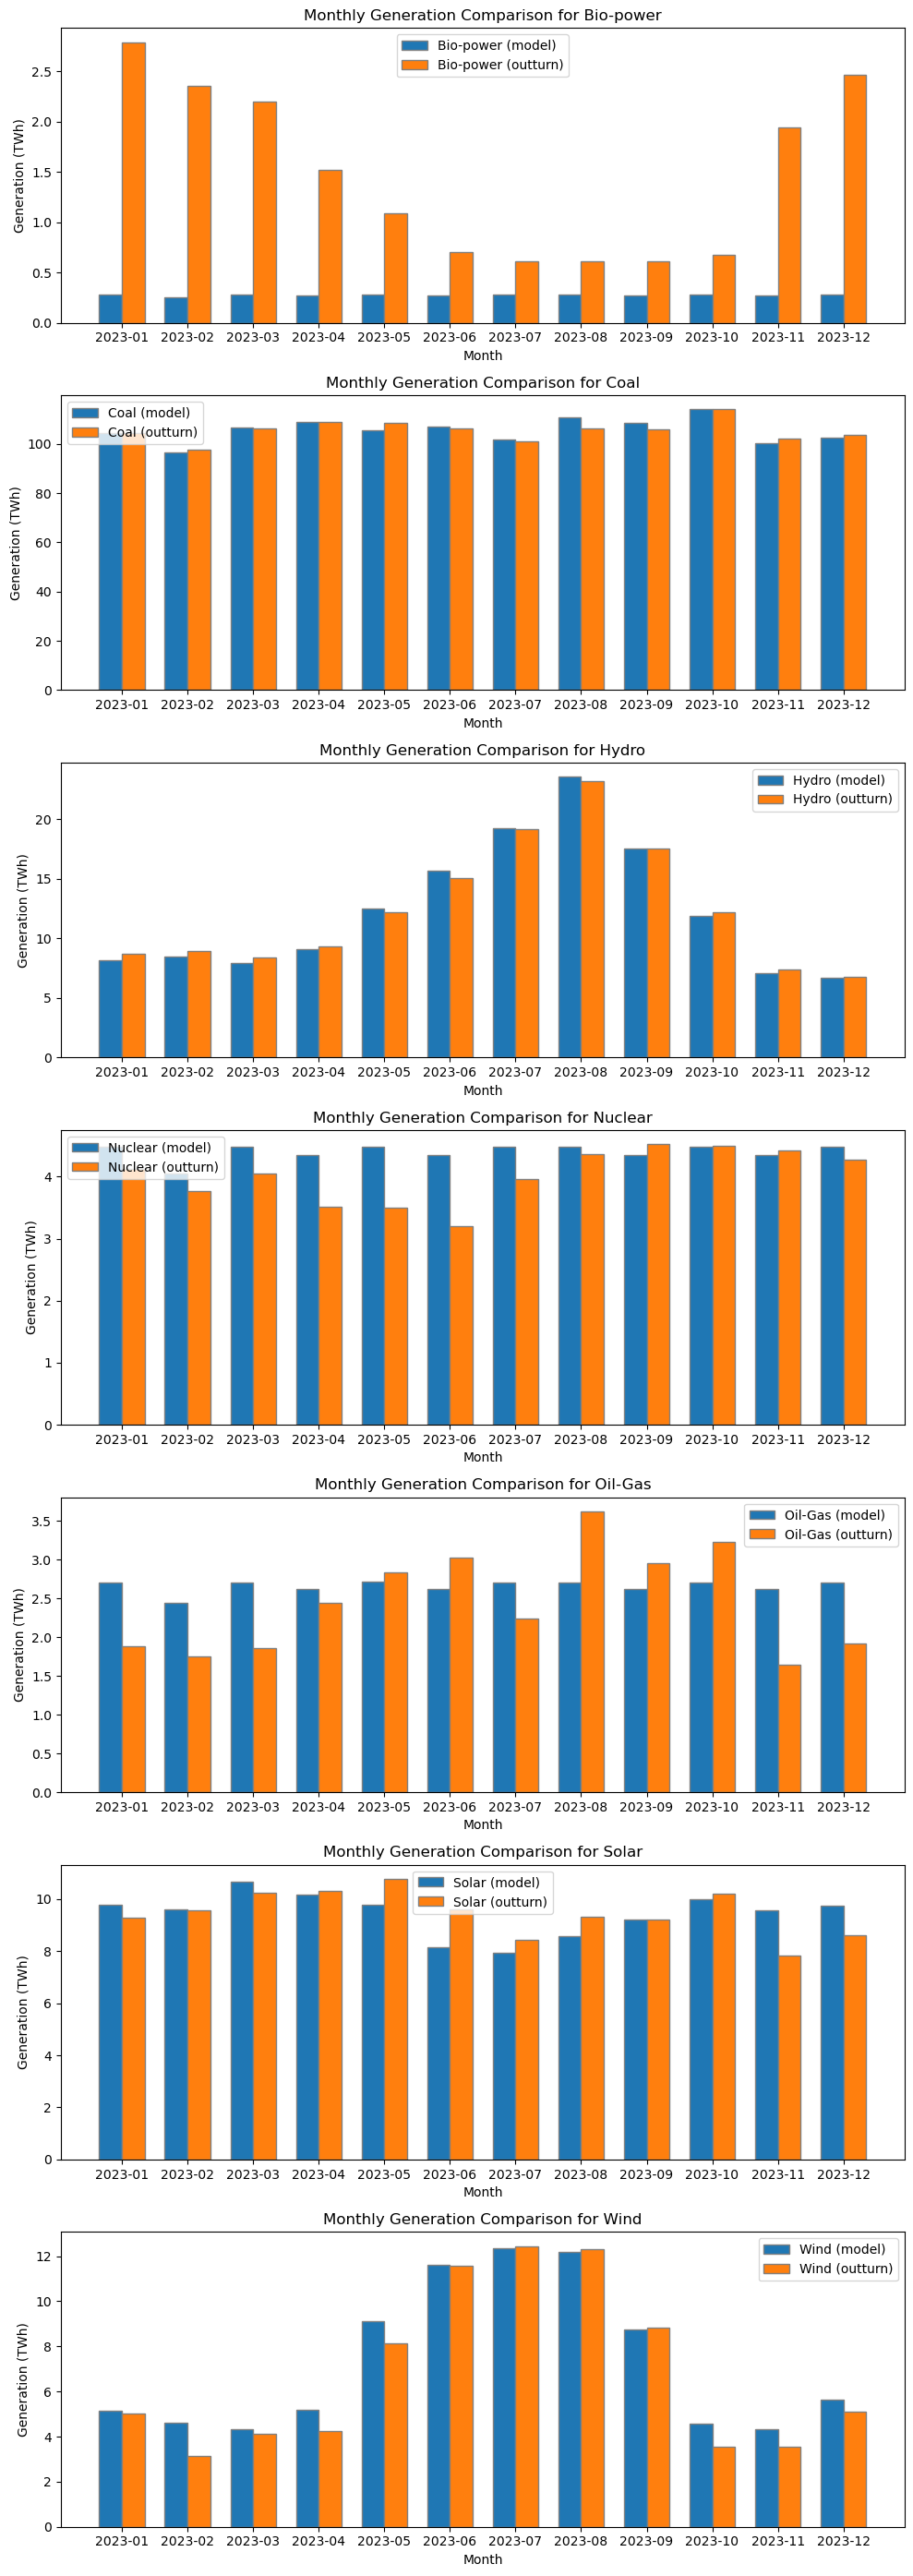

In [29]:
# Define the technologies
technologies = outturn_gen.columns

# Define the width of the bars
bar_width = 0.35

# Define the positions of the bars
r1 = np.arange(len(mgen_grouped))
r2 = [x + bar_width for x in r1]

# Create subplots
fig, axes = plt.subplots(len(technologies), 1, figsize=(10, 4 * len(technologies)))

# Plot each technology
for i, tech in enumerate(technologies):
    ax = axes[i]
    ax.bar(r1, mgen_grouped[tech], color='#1f77b4', width=bar_width, edgecolor='grey', label=f'{tech} (model)')
    ax.bar(r2, outturn_gen[tech], color='#ff7f0e', width=bar_width, edgecolor='grey', label=f'{tech} (outturn)')
    
    # Add labels and title
    ax.set_xlabel('Month')
    ax.set_ylabel('Generation (TWh)')
    ax.set_title(f'Monthly Generation Comparison for {tech}')
    ax.set_xticks([r + bar_width/2 for r in range(len(mgen_grouped))])
    ax.set_xticklabels(mgen_grouped.index.strftime('%Y-%m'))
    
    # Add legend
    ax.legend()

# Adjust layout
plt.tight_layout()
plt.show()

# Save the figure as an image
fig.savefig('./validation/monthly_gen_comparison.png')

In [30]:
# Create a comparison table
comparison_table = pd.concat([mgen_grouped, outturn_gen], axis=1, keys=['Model', 'Outturn'])

# Add a total row
comparison_table.loc['Total'] = comparison_table.sum()

# Display the comparison table
comparison_table.round(1)

Model                                               Outturn  \
Generator Bio-power    Coal  Hydro Nuclear Oil-Gas  Solar  Wind Bio-power   
snapshot                                                                    
2023-01         0.3   104.4    8.1     4.5     2.7    9.8   5.2       2.8   
2023-02         0.3    96.5    8.5     4.1     2.4    9.6   4.6       2.4   
2023-03         0.3   106.7    7.9     4.5     2.7   10.7   4.3       2.2   
2023-04         0.3   108.7    9.1     4.3     2.6   10.2   5.2       1.5   
2023-05         0.3   105.6   12.5     4.5     2.7    9.8   9.1       1.1   
2023-06         0.3   107.0   15.7     4.3     2.6    8.1  11.6       0.7   
2023-07         0.3   101.8   19.3     4.5     2.7    7.9  12.4       0.6   
2023-08         0.3   110.8   23.6     4.5     2.7    8.6  12.2       0.6   
2023-09         0.3   108.3   17.5     4.3     2.6    9.2   8.8       0.6   
2023-10         0.3   114.0   11.8     4.5     2.7   10.0   4.6       0.7   
2023-11         0.3   100.2    7.1     4.3     2.6    9.6   4.3       1.9   
2023-12         0.3   102.5    6.7     4.5     2.7    9.7   5.6       2.5   
Total           3.3  1266.6  147.7    52.8    31.9  113.1  87.9      17.6   

                                                       
Generator    Coal  Hydro Nuclear Oil-Gas  Solar  Wind  
snapshot                                               
2023-01     104.4    8.7     4.1     1.9    9.3   5.0  
2023-02      97.6    8.9     3.8     1.8    9.6   3.1  
2023-03     106.4    8.4     4.0     1.9   10.2   4.1  
2023-04     109.1    9.3     3.5     2.4   10.3   4.2  
2023-05     108.6   12.2     3.5     2.8   10.8   8.1  
2023-06     106.1   15.1     3.2     3.0    9.6  11.6  
2023-07     100.9   19.2     4.0     2.2    8.4  12.4  
2023-08     106.4   23.2     4.4     3.6    9.3  12.3  
2023-09     105.8   17.5     4.5     3.0    9.2   8.9  
2023-10     114.0   12.2     4.5     3.2   10.2   3.5  
2023-11     102.0    7.4     4.4     1.6    7.8   3.5  
2023-12     103.5    6.8     4.3     1.9    8.6   5.1  
Total      1264.7  148.8    48.2    29.4  113.4  82.0

In [31]:
# Calculate the percentage difference between model and outturn
percentage_difference = (comparison_table['Model'] - comparison_table['Outturn']) / comparison_table['Outturn'] * 100

# Rename the columns to indicate percentage difference
percentage_difference.columns = [f'{col} % Difference' for col in percentage_difference.columns]

# Display the percentage difference table
percentage_difference.round(1)

,Bio-power % Difference,Coal % Difference,Hydro % Difference,Nuclear % Difference,Oil-Gas % Difference,Solar % Difference,Wind % Difference
snapshot,,,,,,,
2023-01,-90.0,-0.0,-6.2,9.0,43.8,5.3,2.8
2023-02,-89.3,-1.0,-5.0,7.4,39.5,0.5,47.9
2023-03,-87.3,0.3,-4.9,10.9,45.4,4.1,4.8
2023-04,-82.2,-0.3,-2.4,23.6,7.7,-1.4,22.0
2023-05,-74.3,-2.8,2.4,28.3,-4.2,-9.3,12.5
2023-06,-61.4,0.8,4.0,35.3,-13.5,-15.2,0.4
2023-07,-54.4,1.0,0.5,13.5,20.9,-5.8,-0.7
2023-08,-54.4,4.2,1.5,2.7,-25.2,-8.2,-1.0
2023-09,-56.0,2.4,-0.3,-4.0,-11.4,-0.1,-0.9


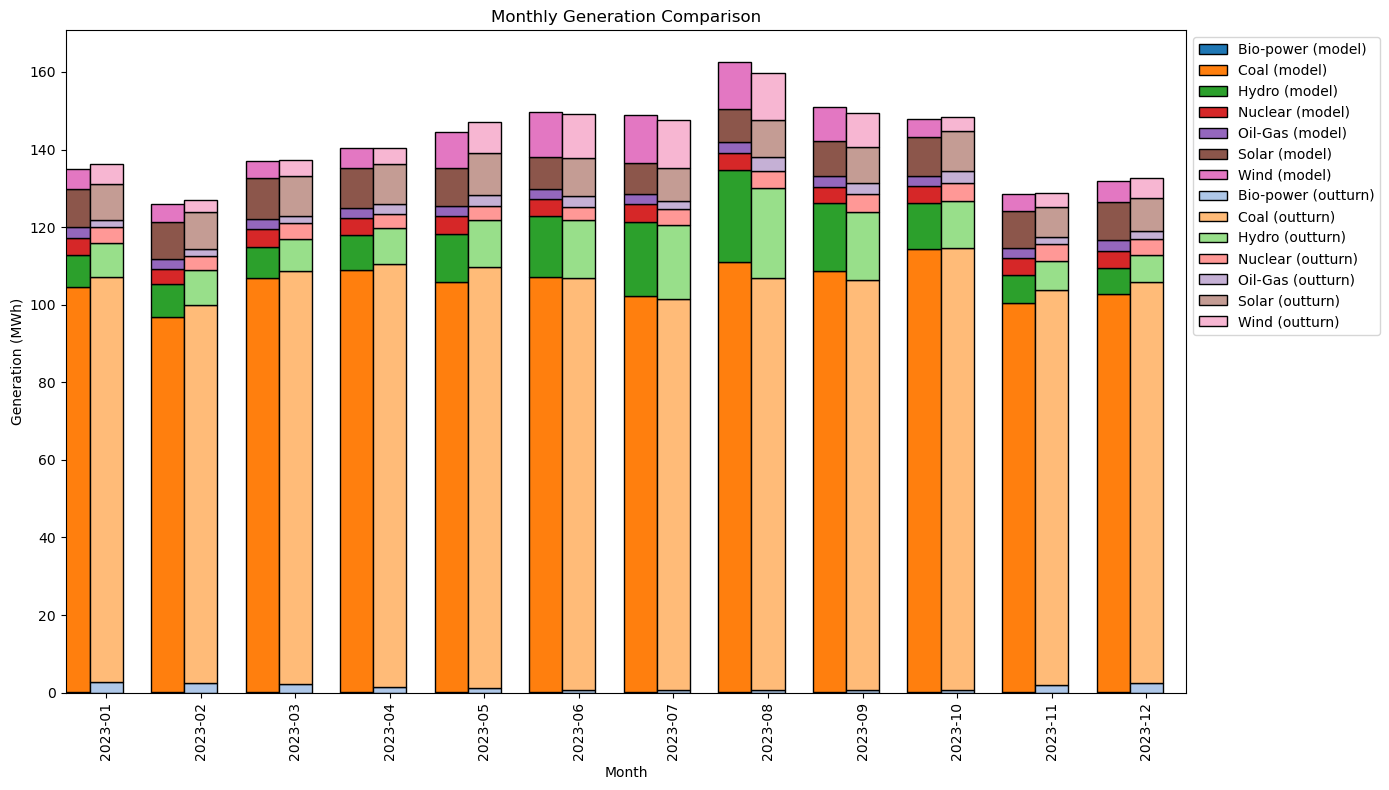

In [32]:
import matplotlib.pyplot as plt

# Define the width of the bars
bar_width = 0.35

# Define the positions of the bars
r1 = range(len(mgen_grouped))
r2 = [x + bar_width for x in r1]

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot mgen_grouped data
mgen_grouped.plot(kind='bar', stacked=True, width=bar_width, position=1, ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f'], edgecolor='black')

# Plot outturn_data
outturn_gen.plot(kind='bar', stacked=True, width=bar_width, position=0, ax=ax, color=['#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#c7c7c7'], edgecolor='black')

# Add labels and title
ax.set_xlabel('Month')
ax.set_ylabel('Generation (MWh)')
ax.set_title('Monthly Generation Comparison')
ax.set_xticks([r + bar_width/2 for r in range(len(mgen_grouped))])
ax.set_xticklabels(mgen_grouped.index.strftime('%Y-%m'))

# Add legend
ax.legend(['Bio-power (model)', 'Coal (model)', 'Hydro (model)', 'Nuclear (model)', 'Oil-Gas (model)', 'Solar (model)', 'Wind (model)',
           'Bio-power (outturn)', 'Coal (outturn)', 'Hydro (outturn)', 'Nuclear (outturn)', 'Oil-Gas (outturn)', 'Solar (outturn)', 'Wind (outturn)'], loc='upper left', bbox_to_anchor=(1, 1))

# Show the plot
plt.tight_layout()
plt.show()

## Capacity factors

In [33]:
n.statistics.capacity_factor()

component    carrier     
StorageUnit  Pumped Hydro    0.001773
Generator    Bioenergy       0.250018
             Coal            0.628845
             Gas             0.147302
             Oil             0.070917
             Onshore Wind    0.218681
             Solar           0.157941
             Uranium         0.799958
             Waste           0.376999
             Water           0.427848
Link         Transmission    0.050660
Load         -                    NaN
dtype: float64

In [34]:
# Get monthly generation
mcf= n.generators_t.p.resample('M').sum()/(n.generators.p_nom*24*30.5)

# # Sum together the columns which have the same name when you remove the last '-' and 2 letters
# mcf.columns =mcf.columns.str.replace(r'-..$', '', regex=True)
# mcf = mcf.groupby(mcf.columns, axis=1).sum()

# Group together Bio-power columns
mcf['Bio-power'] = mcf.filter(like='Bio-power').mean(axis=1)
mcf = mcf.drop(columns=mcf.filter(like='Bio-power').columns.difference(['Bio-power']))

# Group together Solar columns
mcf['Solar'] = mcf.filter(like='Solar').mean(axis=1)
mcf = mcf.drop(columns=mcf.filter(like='Solar').columns.difference(['Solar']))

# Group together hydro columns
mcf['Hydro'] = mcf.filter(like='hydro').mean(axis=1)
mcf = mcf.drop(columns=mcf.filter(like='hydro').columns.difference(['hydro']))

# Rename index
mcf.index = mcf.index.to_period('M')

mcf.head()

Generator,Wind-INDEA-wind,Wind-INDNE-wind,Wind-INDNO-wind,Wind-INDSO-wind,Wind-INDWE-wind,circulating-fluidized-bed-INDSO-coal,circulating-fluidized-bed-INDWE-coal,coal-unspecified-INDEA-coal,coal-unspecified-INDSO-coal,coal-unspecified-INDWE-coal,...,subcritical-INDWE-waste,supercritical-INDEA-coal,supercritical-INDNO-coal,supercritical-INDSO-coal,supercritical-INDWE-coal,ultrasupercritical-INDNO-coal,ultrasupercritical-INDWE-coal,Bio-power,Solar,Hydro
snapshot,,,,,,,,,,,,,,,,,,,,,
2023-01,NaN,NaN,0.126200,0.186162,0.126107,0.406557,0.406557,0.406557,0.406557,0.406557,...,0.505628,0.714465,0.971083,0.922039,0.837400,1.016393,1.016393,0.190779,0.155356,0.277179
2023-02,NaN,NaN,0.157693,0.154193,0.114942,0.367213,0.367213,0.367213,0.369670,0.367213,...,0.463096,0.695200,0.850870,0.910295,0.814302,0.918033,0.918033,0.172264,0.152225,0.281243
2023-03,NaN,NaN,0.178618,0.122234,0.123630,0.432091,0.406557,0.406557,0.445857,0.406557,...,0.469613,0.826533,0.840537,1.011783,0.860746,0.967962,1.005910,0.190640,0.171986,0.258122
2023-04,NaN,NaN,0.182154,0.141588,0.160475,0.401065,0.393443,0.393443,0.412182,0.393443,...,0.512639,0.907200,0.837733,0.980073,0.883087,0.935121,0.975635,0.184585,0.166275,0.290676
2023-05,NaN,NaN,0.372807,0.258506,0.259359,0.406557,0.406557,0.406557,0.406557,0.406557,...,0.427441,0.931087,0.893009,0.981374,0.814630,0.988527,0.998740,0.190686,0.159181,0.377442


In [35]:
# Create a dictionary for grouping columns
grouping_dict = {
    'Bio-power': 'Bio-power',
    'Solar': 'Solar', 
    'Wind': 'Wind', 
    'circulating-fluidized-bed': 'Coal',
    'coal-unspecified': 'Coal',
    'combined-cycle': 'Oil-Gas',
    'gas-turbine': 'Oil-Gas', 
    'hydro-reservoir': 'Hydro',
    'hydro-run-of-river': 'Small-Hydro',
    'hydro-unspecified': 'Hydro',
    'Hydro': 'Hydro',
    'internal-combustion-combined-cycle': 'Oil-Gas',
    'oil-unspecified': 'Oil-Gas',
    'pressurized-heavy-water-reactor': 'Nuclear',
    'pressurized-water-reactor': 'Nuclear',
    'steam-turbine': 'Oil-Gas', 
    'subcritical': 'Coal', 
    'supercritical': 'Coal', 
    'ultrasupercritical': 'Coal'
}

# Group columns by the text before '-IND' and sum
mcf_grouped = mcf.groupby(mcf.columns.str.split('-IND').str[0].map(grouping_dict), axis=1).mean()

In [36]:
# Pull in outturn data
# Remember that MU is Millions of Units (of kWh), so 1 MU is 1 GWh
outturn_cf = (
    pd
    .read_excel('./india_cf_2023.xlsx')
    .iloc[:-4]
    .set_index('Parameter')
    .T
    .multiply(0.01)
)
outturn_cf.index.name = 'snapshot'
outturn_cf.columns = outturn_cf.columns.str.replace(r' - .*$', '', regex=True)
outturn_cf.columns.name = 'Generator'
outturn_cf.index = pd.to_datetime(outturn_cf.index).to_period('M')
outturn_cf = outturn_cf.rename(columns={'Bio Power': 'Bio-power','Oil & Gas': 'Oil-Gas'})
outturn_cf = outturn_cf[sorted(outturn_cf.columns)]

# Merge the two columns containing 'hydro' together
outturn_cf['Hydro'] = outturn_cf.filter(like='Hydro').mean(axis=1)
outturn_cf = outturn_cf.drop(columns=outturn_cf.filter(like='Hydro').columns.difference(['Hydro']))

# Arrange the columns alphabetically
outturn_cf = outturn_cf[sorted(outturn_gen.columns)]

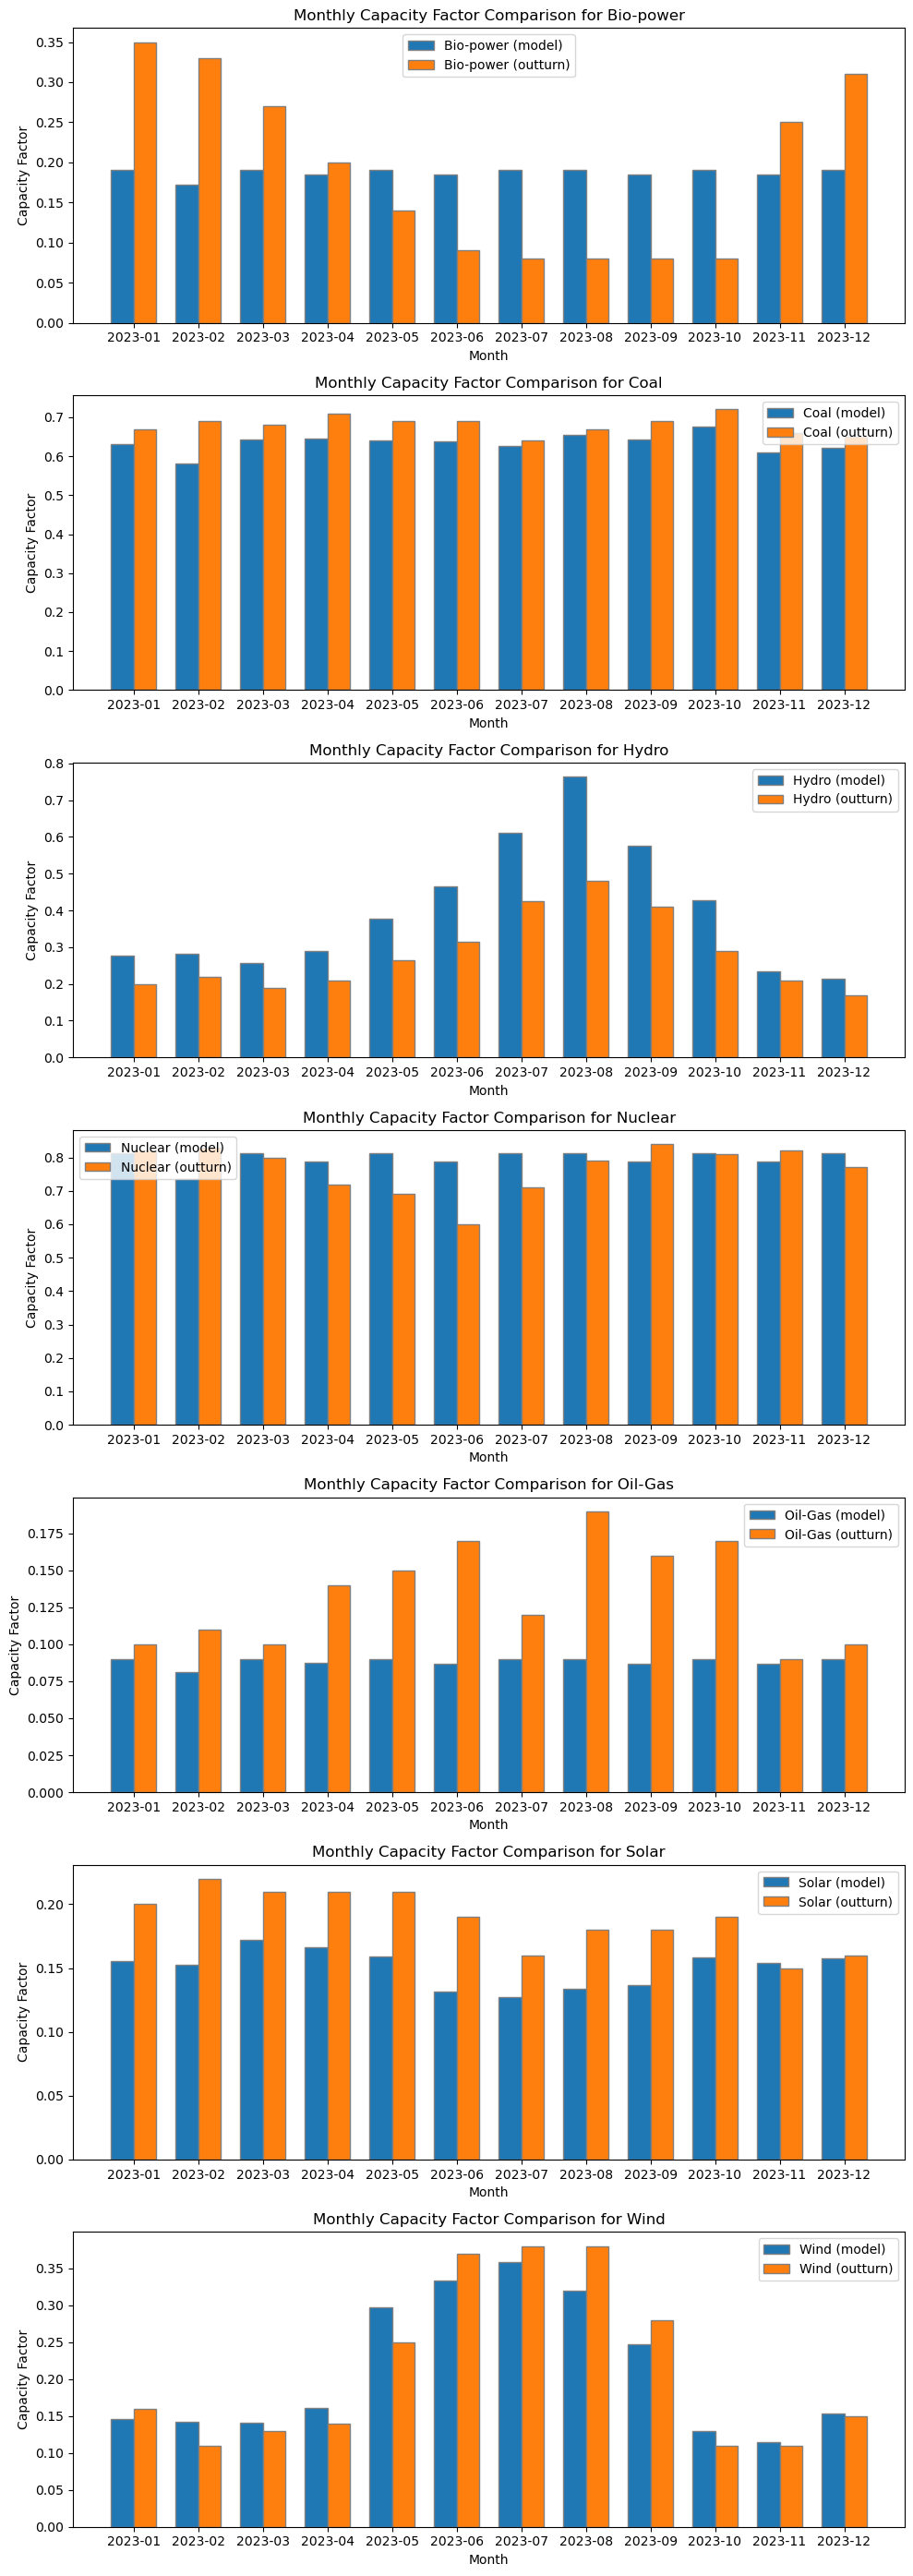

In [37]:
# Define the technologies
technologies = outturn_cf.columns

# Define the width of the bars
bar_width = 0.35

# Define the positions of the bars
r1 = np.arange(len(mcf_grouped))
r2 = [x + bar_width for x in r1]

# Create subplots
fig, axes = plt.subplots(len(technologies), 1, figsize=(10, 4 * len(technologies)))

# Plot each technology
for i, tech in enumerate(technologies):
    ax = axes[i]
    ax.bar(r1, mcf_grouped[tech], color='#1f77b4', width=bar_width, edgecolor='grey', label=f'{tech} (model)')
    ax.bar(r2, outturn_cf[tech], color='#ff7f0e', width=bar_width, edgecolor='grey', label=f'{tech} (outturn)')
    
    # Add labels and title
    ax.set_xlabel('Month')
    ax.set_ylabel('Capacity Factor')
    ax.set_title(f'Monthly Capacity Factor Comparison for {tech}')
    ax.set_xticks([r + bar_width/2 for r in range(len(mcf_grouped))])
    ax.set_xticklabels(mcf_grouped.index.strftime('%Y-%m'))
    
    # Add legend
    ax.legend()

# Adjust layout
plt.tight_layout()
plt.show()

# Save the figure as an image
fig.savefig('./validation/monthly_cf_comparison.png')